# Week 08 (training): Build the AI/ML pipeline and train the unconditional model

Last week you built every diffusion-specific piece of mathematics the model
needs — in pure numpy, with every line transparent and debuggable. The forward
process that maps a clean residual to noise across T = 200 timesteps, the
cosine noise schedule that defines α_t and σ_t at every t, and the empirical
verifications that the corruption behaves the way the math says it should.
The window table, the stratified split, and the schedule are all saved to
`diffusion_windows.parquet`. What you have *not* built is anything with
learnable parameters.

That changes this week. The forward apparatus from Week 07 will be reused
unchanged; on top of it we add the **reverse process** — a small denoising
neural network whose job is to estimate ε from r_t, trained in PyTorch with
PyTorch Lightning. By the end of *this* notebook you will have trained two
checkpoints — the full t-aware model and the t-blind ablation. The companion
notebook `09b_unconditioned_evaluate.ipynb` loads those checkpoints and runs the
distributional verification (Task 43) and the ablation comparison (Task 44).

**Why two notebooks.** Definitions are stable; evaluations are exploratory. By
putting every class and function in `unconditioned_infrastructure.py`, training and evaluation
can each import the same definitions, and checkpoints carry the bridge between
them. If you need to re-evaluate a checkpoint with a different metric tomorrow,
you do not need to retrain — you open the evaluation notebook and load.

**Strategic context.** This week is the most code-heavy of the three. The
conceptual lift is smaller than Week 07's diffusion math — the hard ideas
(forward process, schedule, ε-prediction) are already in your toolkit. What
this week demands is *integration*: turning the numpy schedule into a PyTorch
buffer, turning the residual table into a Dataset, turning the training
equation into a Lightning training step, and watching the whole thing learn.
Most of you will encounter the canonical AI/ML pipeline (Dataset → DataLoader
→ Model → LightningModule → Trainer) for the first time here. The pipeline is
not diffusion-specific — every PyTorch project you ever build will have the
same five pieces — but each piece has a diffusion-specific wrinkle.

**One deliberate omission this week: conditioning.** The Week 09 model will
condition on (cycle amplitude, universal-path latitude) and run through
`compute_global_nll`. This week we train the *unconditional* version: it
learns the marginal distribution of residuals across all training cycles and
can sample plausible residuals, but it cannot target a specific window. One
new idea per week.


In [5]:
!pip install -q ipython==7.34.0 decorator==4.4.2

In [4]:
import IPython
print(IPython.__version__)

7.34.0


In [7]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [10]:
!pip install pytorch-lightning wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.8 MB/s eta 0:00:00


In [11]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb

In [14]:
# ── locate repo root + week-08/09 artifacts (split across two folders) ─────
# The week-08 deliverables are currently spread between weeks/week_08/ and
# weeks/week_09/. We search both for each artifact independently so the
# notebook works regardless of where any given file sits.
def _find(filename, search_dirs):
    for d in search_dirs:
        p = os.path.join(d, filename)
        if os.path.isfile(p):
            return p
    return None

_cwd = os.getcwd()
_search_dirs_candidates = []

# Explicitly add the directories where the files are located, based on repo_path
_search_dirs_candidates.append(os.path.join(repo_path, "weeks", "week_09"))
_search_dirs_candidates.append(os.path.join(repo_path, "weeks", "week_08"))

# Original logic, adapted to ensure it doesn't accidentally override
# if `_cwd` is not within the repo structure, the `_base` loop will likely not add anything useful.
# It's safer to prepend the `repo_path` based directories.
for _base in [_cwd] + [os.path.abspath(os.path.join(_cwd, *[".." ] * i)) for i in range(0, 5)]:
    for _sub in [("weeks", "week_09"), ("weeks", "week_08")]:
        _candidate = os.path.join(_base, *_sub)
        if os.path.isdir(_candidate):
            _search_dirs_candidates.append(_candidate)
    # Also handle being launched from inside a week_XX dir
    if ("week_08" in _base or "week_09" in _base) and os.path.isdir(_base):
        _search_dirs_candidates.append(_base)

# Filter for unique and existing directories
_search_dirs = []
for d in _search_dirs_candidates:
    if os.path.isdir(d) and d not in _search_dirs:
        _search_dirs.append(d)

_models_py        = _find("unconditioned_infrastructure.py",            _search_dirs)
_parquet_path     = _find("diffusion_windows.parquet", _search_dirs)
_classical_py     = _find("butterflAI_model.py",       _search_dirs)
_classical_weights = _find("official_model.npz",       _search_dirs)

_missing = [n for n, p in [
    ("unconditioned_infrastructure.py",            _models_py),
    ("diffusion_windows.parquet", _parquet_path),
    ("butterflAI_model.py",       _classical_py),
    ("official_model.npz",        _classical_weights),
] if p is None]
if _missing:
    raise FileNotFoundError(
        f"Cannot locate {_missing} under weeks/week_08 or weeks/week_09. "
        f"Searched: {_search_dirs}"
    )

# Repo root is the parent of whichever weeks/ dir we found
_repo_root = os.path.abspath(os.path.join(os.path.dirname(_models_py), "..", ".."))

# Make every directory that holds an importable module reachable
for _p in [_repo_root, os.path.dirname(_models_py), os.path.dirname(_classical_py)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── import everything class-and-function-level from the week 08 script ─────
from unconditioned_infrastructure import (
    make_cosine_schedule, ResidualDataset,
    sinusoidal_embedding, TimestepEmbedding, DiffusionMLP, DiffusionLightning,
    sample, SampleQualityCallback,
)

# ── load Week 07 outputs ───────────────────────────────────────────────────
windows_df = pd.read_parquet(_parquet_path)

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

# ── classical ButterflAI model (for ad-hoc inspection only this week) ──────
from butterflAI_model import ButterflAIModel
classical = ButterflAIModel(_classical_weights)

# ── cosine schedule (single source of truth, lives in the script) ──────────
T = 200
alpha_np, sigma_np, _alpha_bar_np = make_cosine_schedule(T=T, s=0.008)

print(f"Loaded {len(windows_df)} windows from {_parquet_path}")
print(f"  splits : {windows_df['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles : {sorted(windows_df['cycle'].unique())}")
print(f"  schedule: T={T}, arrays length {len(alpha_np)}")
print(classical)

Loaded 373 windows from /content/butterflai/weeks/week_08/diffusion_windows.parquet
  splits : {'test': 86, 'train': 232, 'val': 55}
  cycles : [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
  schedule: T=200, arrays length 201
<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>


---
## Task 33 — `ResidualDataset` (defined in `unconditioned_infrastructure.py`)

The dataset class is one of the cleanest things to put in the script: its
definition is short, stable across training and evaluation, and shared
between the two notebooks. Open `unconditioned_infrastructure.py` to see the full code.

Two design points worth pausing on:

**The dataset is *boring*** by intent. `__getitem__` returns just the clean
residual r — no noise injection, no timestep sampling. The (r_t, t, ε) triple
the network trains on is built *inside* the Lightning training step, on the
fly, per batch. This separation is deliberate: it lets you change the timestep
sampling distribution or the loss weighting without ever touching the dataset.

**Per-bin standardization at construction time.** The 15 latitude bins have
order-of-magnitude different residual scales (bin 14 is near-zero, bin 4 is
~10× larger). Without standardization, the diffusion model would spend most
of its capacity learning that scale difference rather than the cross-cycle
structure that actually matters. The Dataset standardizes once at construction
and exposes `bin_means` / `bin_stds` so the sampler can de-standardize when
returning samples to physical units. Those statistics also ride along with
the trained LightningModule (as buffers) so `09b_unconditioned_evaluate.ipynb` can de-
standardize without needing the original `train_dataset` object.

## Task 34 — Test and visualize the dataset


len(train_dataset) = 232
len(val_dataset)   = 55

Single-sample sanity check: type, shape, dtype, finiteness all OK.


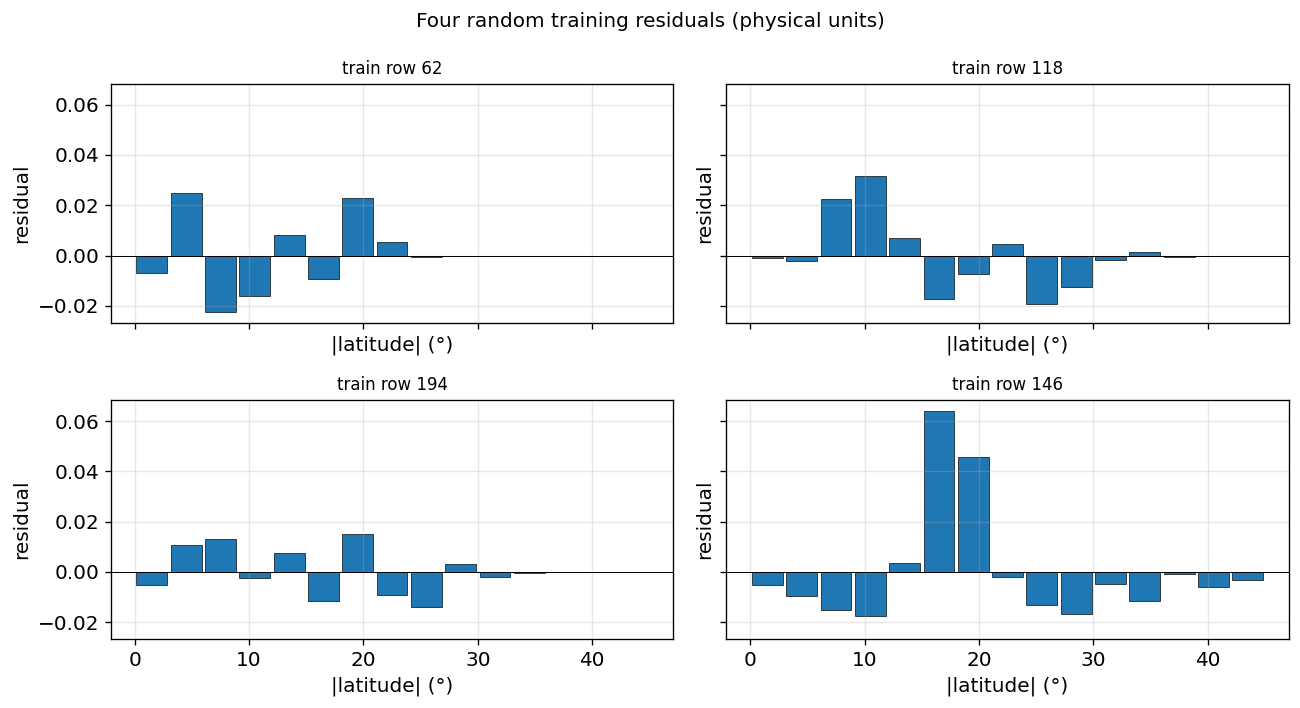

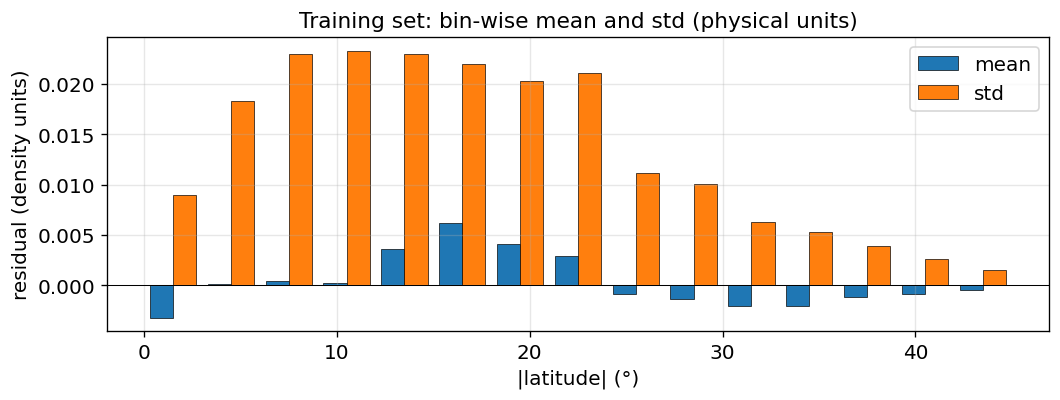

In [15]:
# ── Task 34: instantiate datasets, sanity-check, visualize ─────────────────
train_dataset = ResidualDataset(windows_df, "train")
val_dataset   = ResidualDataset(windows_df, "val")

print(f"len(train_dataset) = {len(train_dataset)}")
print(f"len(val_dataset)   = {len(val_dataset)}")

first_sample = train_dataset[0]
assert isinstance(first_sample, torch.Tensor),     f"type is {type(first_sample)}"
assert tuple(first_sample.shape) == (15,),         f"shape is {tuple(first_sample.shape)}"
assert first_sample.dtype == torch.float32,        f"dtype is {first_sample.dtype}"
assert torch.isfinite(first_sample).all().item(),  "first_sample contains NaN or Inf"
print("\nSingle-sample sanity check: type, shape, dtype, finiteness all OK.")

# All plots are in *physical* residual units — de-standardize for display.
bin_means_np = train_dataset.bin_means.numpy()
bin_stds_np  = train_dataset.bin_stds.numpy()

rng  = np.random.default_rng(0)
idxs = rng.choice(len(train_dataset), size=4, replace=False)
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)
for ax, i in zip(axes.flat, idxs):
    r = train_dataset[int(i)].numpy() * bin_stds_np + bin_means_np
    ax.bar(BIN_CENTERS, r, width=BIN_WIDTH * 0.9, color="C0",
           edgecolor="black", linewidth=0.4)
    ax.axhline(0, color="k", linewidth=0.6)
    ax.set_title(f"train row {int(i)}", fontsize=10)
    ax.set_xlabel("|latitude| (°)"); ax.set_ylabel("residual")
fig.suptitle("Four random training residuals (physical units)", fontsize=12)
plt.tight_layout(); plt.show()

# Bin-wise stats across the whole training split
all_train      = torch.stack([train_dataset[i] for i in range(len(train_dataset))]).numpy()
all_train_phys = all_train * bin_stds_np + bin_means_np
all_val        = torch.stack([val_dataset[i]   for i in range(len(val_dataset))]).numpy()
all_val_phys   = all_val   * bin_stds_np + bin_means_np

bin_mean = all_train_phys.mean(axis=0)
bin_std  = all_train_phys.std(axis=0)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(BIN_CENTERS - BIN_WIDTH * 0.2, bin_mean, width=BIN_WIDTH * 0.4,
       label="mean", color="C0", edgecolor="black", linewidth=0.4)
ax.bar(BIN_CENTERS + BIN_WIDTH * 0.2, bin_std, width=BIN_WIDTH * 0.4,
       label="std",  color="C1", edgecolor="black", linewidth=0.4)
ax.axhline(0, color="k", linewidth=0.6)
ax.set_xlabel("|latitude| (°)"); ax.set_ylabel("residual (density units)")
ax.set_title("Training set: bin-wise mean and std (physical units)")
ax.legend(); plt.tight_layout(); plt.show()


---
## Task 35 — Build the DataLoaders

A `Dataset` is an indexed collection; a `DataLoader` is the object that
samples batches from it. `shuffle=True` for the training loader (SGD needs
roughly-i.i.d. batches; without it, gradient bias accumulates over each epoch)
and `shuffle=False` for the validation loader (so successive runs produce
identical batch orderings and metrics are reproducible).


In [16]:
# ── Task 35: DataLoaders ───────────────────────────────────────────────────
BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

for name, loader in [("train", train_loader), ("val", val_loader)]:
    batch = next(iter(loader))
    assert isinstance(batch, torch.Tensor) and batch.dtype == torch.float32
    assert batch.shape[1] == 15
    print(f"{name:5s}: {len(loader):3d} batches/epoch, first batch shape={tuple(batch.shape)}")


train:   4 batches/epoch, first batch shape=(64, 15)
val  :   1 batches/epoch, first batch shape=(55, 15)


---
## Task 36 — Sinusoidal timestep embedding (defined in `unconditioned_infrastructure.py`)

The diffusion-specific architectural primitive. `sinusoidal_embedding(t, dim)`
maps integer timesteps to dense vectors via sines and cosines at log-spaced
frequencies. Different t values produce vectors that point in different
directions in this dim-dimensional space, which is what lets a single network
behave differently at different noise levels.

We visualize the embedding here to build intuition. The function itself is
fixed (no learnable parameters); the `TimestepEmbedding` module in Task 37
wraps it in a small learnable MLP.


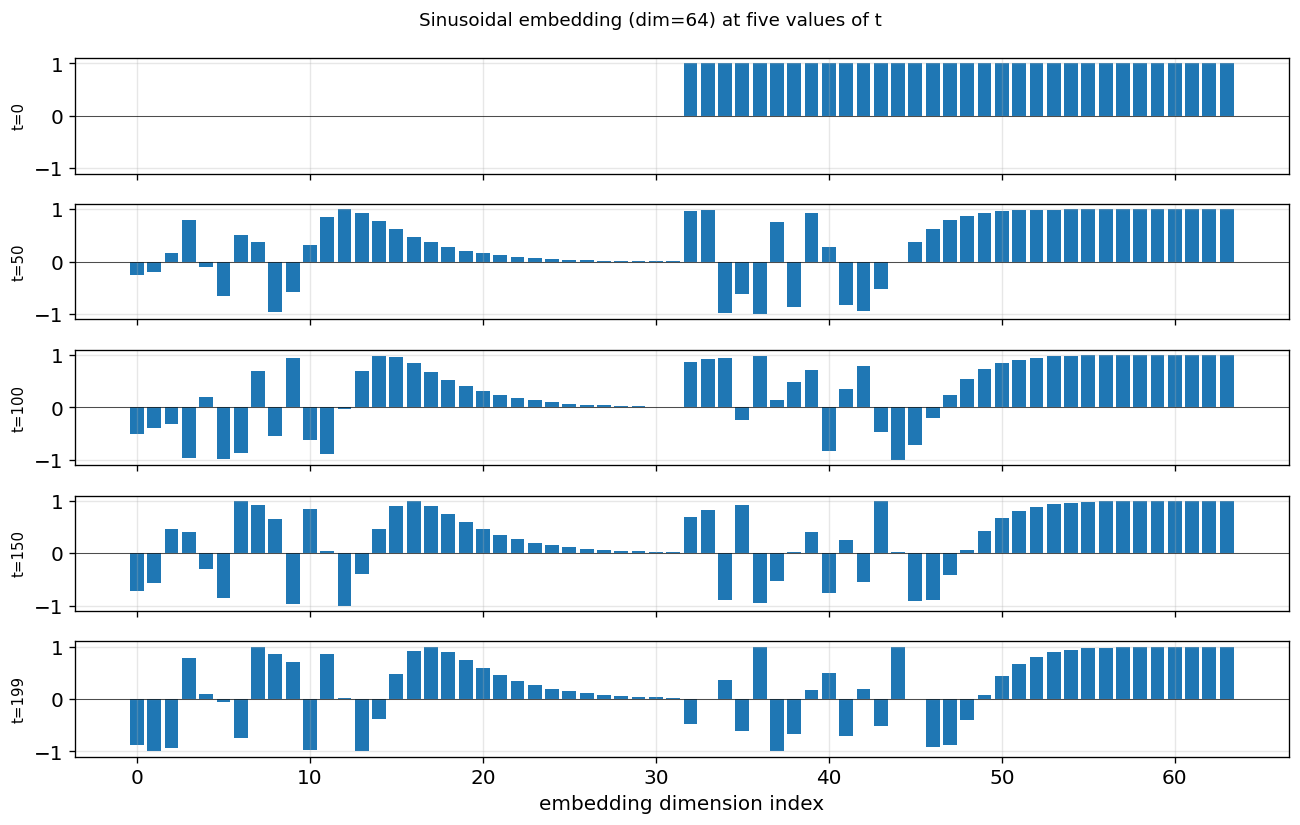

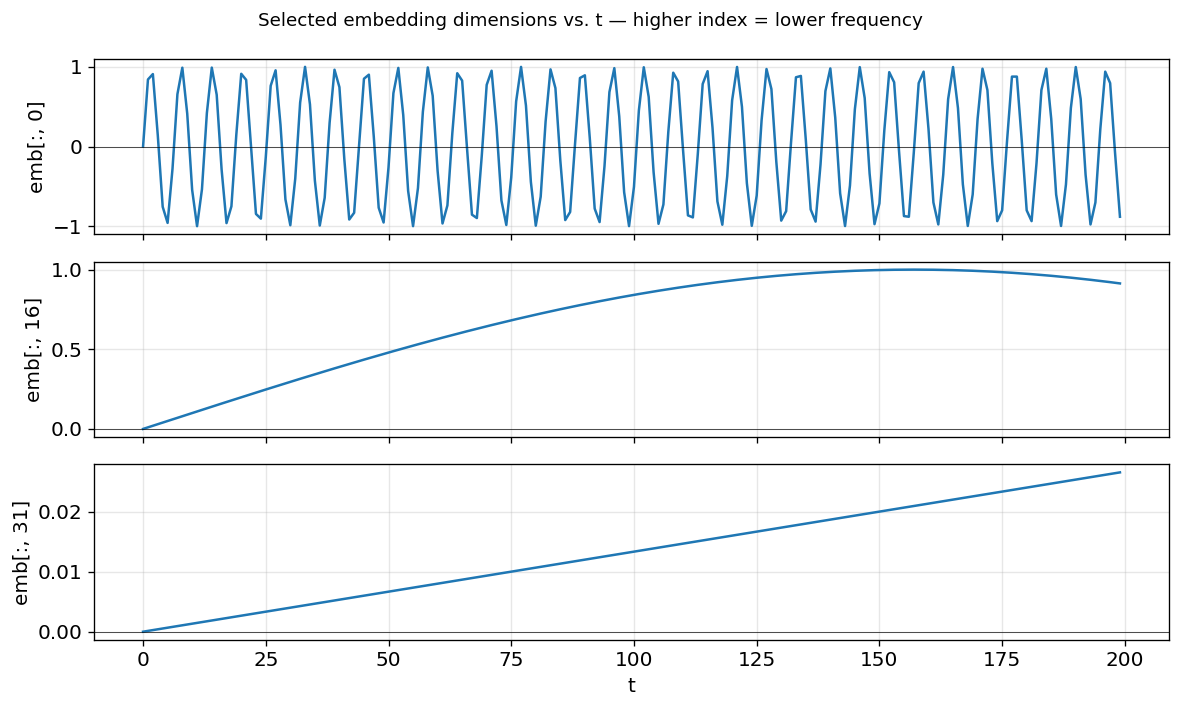

In [17]:
# ── Visualization 1: bar chart of the 64-dim embedding at five t values ───
dim_demo = 64
t_demo   = torch.tensor([0, T // 4, T // 2, 3 * T // 4, T - 1], dtype=torch.long)
emb_demo = sinusoidal_embedding(t_demo, dim_demo).numpy()

fig, axes = plt.subplots(5, 1, figsize=(11, 7), sharex=True)
for ax, ti, row in zip(axes, t_demo.tolist(), emb_demo):
    ax.bar(np.arange(dim_demo), row, color="C0", edgecolor="none")
    ax.axhline(0, color="k", linewidth=0.4)
    ax.set_ylabel(f"t={ti}", fontsize=9); ax.set_ylim(-1.1, 1.1)
axes[-1].set_xlabel("embedding dimension index")
fig.suptitle(f"Sinusoidal embedding (dim={dim_demo}) at five values of t", fontsize=11)
plt.tight_layout(); plt.show()

# ── Visualization 2: chosen dimensions vs. t ──────────────────────────────
t_range  = torch.arange(0, T, dtype=torch.long)
emb_full = sinusoidal_embedding(t_range, dim_demo).numpy()

dims_to_plot = [0, 16, 31]
fig, axes = plt.subplots(len(dims_to_plot), 1, figsize=(10, 6), sharex=True)
for ax, d in zip(axes, dims_to_plot):
    ax.plot(t_range.numpy(), emb_full[:, d], lw=1.5)
    ax.axhline(0, color="k", linewidth=0.4)
    ax.set_ylabel(f"emb[:, {d}]")
axes[-1].set_xlabel("t")
fig.suptitle("Selected embedding dimensions vs. t — higher index = lower frequency", fontsize=11)
plt.tight_layout(); plt.show()


---
## Task 37 — `TimestepEmbedding` (defined in `unconditioned_infrastructure.py`)

The wrapping pattern *fixed positional encoding → learnable projection* is
standard across Transformer-style architectures. It separates "how do I
represent integer position as a vector" (solved analytically by the sinusoidal
formula) from "what t-information does my downstream network find useful"
(solved by gradient descent through the MLP).

## Task 38 — `DiffusionMLP` (defined in `unconditioned_infrastructure.py`)

The main ε-prediction network. Constructor flag `use_timestep_embedding`
toggles whether the network has any path through which t can affect its
output — `True` gives the full model, `False` gives the t-blind ablation we
will train alongside the full one in this notebook and compare against in
the evaluation notebook.

## Task 39 — t-sensitivity sanity check

Before training anything, two model bugs to rule out. The first is mundane:
shape mismatches at the input or output of the MLP, which will raise a clear
PyTorch error. The second is much more dangerous: a model that *looks* fine —
accepts (r_t, t), produces an output of the right shape, trains without
error — but silently ignores t even when `use_timestep_embedding=True`. None
of these failures raise. They only become visible when the ablation in
Task 44 produces "the timestep embedding doesn't help" — at which point you
cannot tell whether the embedding is genuinely unhelpful or simply broken.

The defense: hold r_t fixed, vary t, verify the output measurably changes for
the full model and is exactly invariant for the blind one.


In [18]:
# ── Task 39: t-sensitivity sanity check on fresh (untrained) models ───────
torch.manual_seed(1)
model_full_sanity  = DiffusionMLP(use_timestep_embedding=True)
model_blind_sanity = DiffusionMLP(use_timestep_embedding=False)

for name, m in [("full", model_full_sanity), ("blind", model_blind_sanity)]:
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:5s}: {n_params:>7,d} parameters")

# Same r_t broadcast over 5 timesteps via einops.repeat (no expand / tile).
r_t_fixed = torch.randn(15)
t_values  = torch.tensor([0, T // 4, T // 2, 3 * T // 4, T - 1], dtype=torch.long)
r_t_batch = repeat(r_t_fixed, "d -> n d", n=t_values.shape[0])

with torch.no_grad():
    out_full  = model_full_sanity(r_t_batch,  t_values)
    out_blind = model_blind_sanity(r_t_batch, t_values)

# Blind outputs must be exactly equal across all t.
for i in range(5):
    for j in range(5):
        assert torch.allclose(out_blind[i], out_blind[j]), \
            "blind model outputs differ across t — it should be t-blind!"

print(f"\nfull  outputs differ across t : max pairwise L2 = "
      f"{(out_full[None] - out_full[:, None]).norm(dim=-1).max():.4f}")
print(f"blind outputs differ across t : exactly 0 (verified)")
print("\nt-sensitivity check passed on fresh models.")


full :  78,223 parameters
blind:  37,007 parameters

full  outputs differ across t : max pairwise L2 = 0.0077
blind outputs differ across t : exactly 0 (verified)

t-sensitivity check passed on fresh models.


---
## Task 40 — `DiffusionLightning` (defined in `unconditioned_infrastructure.py`)

The LightningModule wraps the model with everything it needs to train:
schedule buffers (`alpha`, `sigma`), per-bin standardization stats
(`bin_means`, `bin_stds`), the MSE-on-ε training step, AdamW with separate
no-decay group for biases and 1-D parameters, and an optional LR scheduler
(`"plateau"` or `"cosine"`).

The `training_step` is fully **schedule-agnostic** — it looks up
`self.alpha[t]` and `self.sigma[t]` from the buffers and uses them; it does
not know whether those values came from a cosine, linear, or any other
schedule formula. Swapping schedules later only requires changing what you
pass to the constructor.

The constructor calls `save_hyperparameters(ignore=[...])` so that
`load_from_checkpoint` in `09b_unconditioned_evaluate.ipynb` works cleanly — you only need
to pass the `model`, `alpha`, `sigma`, `bin_means`, `bin_stds` at load time
(everything else is restored from the saved scalars).

## Task 41 — Train the full (t-aware) unconditional diffusion model


In [19]:
# ── Task 41: train the full t-aware model ─────────────────────────────────
from infrastructure.utils.reproducibility import set_all_seeds
set_all_seeds(42)

MAX_EPOCHS = 500

model_full      = DiffusionMLP(use_timestep_embedding=True)
lightning_full  = DiffusionLightning(
    model=model_full, alpha=alpha_np, sigma=sigma_np, T=T, lr=1e-3,
    scheduler="cosine", weight_decay=1e-4,
    bin_means=train_dataset.bin_means, bin_stds=train_dataset.bin_stds,
)

# WandB if available, otherwise CSVLogger so the run still produces a loss
# history we can plot below.
try:
    logger_full = WandbLogger(
        project="butterflai-wk08_amj",
        name=f"unconditional_full_b{BATCH_SIZE}_e{MAX_EPOCHS}_script",
        save_dir="./wandb_logs",
    )
except Exception as _e:
    print(f"WandB unavailable ({_e}); using CSVLogger.")
    logger_full = CSVLogger("./csv_logs", name="unconditional_full")

sample_quality_cb_full = SampleQualityCallback(
    train_samples  = all_train_phys,        # in physical units; sample() returns physical too
    val_samples    = all_val_phys,
    every_n_epochs = 100,
    n_compare      = 500,
    bin_centers    = BIN_CENTERS,           # enables the end-of-training panels
    bin_width      = BIN_WIDTH,
)

trainer_full = pl.Trainer(
    max_epochs          = MAX_EPOCHS,
    logger              = logger_full,
    accelerator         = "auto",
    devices             = "auto",
    log_every_n_steps   = 10,
    enable_progress_bar = False,
    callbacks           = [sample_quality_cb_full],
)

trainer_full.fit(lightning_full, train_loader, val_loader)

ckpt_full = "./ckpt_full.ckpt"
trainer_full.save_checkpoint(ckpt_full)
print(f"\nSaved {ckpt_full}.")

# Quick loss-curve glance (only if CSVLogger was used — WandB has live curves).
if isinstance(logger_full, CSVLogger):
    csv_path = Path(logger_full.log_dir) / "metrics.csv"
    if csv_path.exists():
        h = pd.read_csv(csv_path)
        fig, ax = plt.subplots(figsize=(9, 4))
        if "epoch" in h.columns and "train_loss" in h.columns:
            tr = h.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].mean()
            ax.plot(tr.index, tr.values, label="train_loss", color="C0")
            if "val_loss" in h.columns:
                va = h.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].mean()
                ax.plot(va.index, va.values, label="val_loss", color="C1")
        ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE(ε̂, ε)")
        ax.set_title("Full model: training and validation loss")
        ax.legend(); plt.tight_layout(); plt.show()

try: wandb.finish()
except Exception: pass


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: claudiaholland (butterflai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ DiffusionMLP │ 78.2 K │ train │     0 │
└───┴───────┴──────────────┴────────┴───────┴───────┘

Trainable params: 78.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 78.2 K                                                                                               
Total estimated model params size (MB): 0.313                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=500` reached.
INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.



Saved ./ckpt_full.ckpt.


epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████
eval/end_of_training,▁
sample_cov_frob,█▁▁▁▁
sample_std_mse,█▁▁▁▁
train_loss,█▆▃▃▂▃▃▂▃▃▃▂▃▃▂▃▃▂▂▂▂▁▂▂▁▂▁▁▃▂▂▂▂▁▁▁▂▁▁▂
trainer/global_step,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇██
val_loss,█▆▄▃▂▂▃▂▂▃▃▂▁▂▂▂▂▂▃▂▃▂▄▂▃▂▂▂▂▂▃▂▂▁▁▂▂▃▂▂
val_sample_cov_frob,█▁▁▁▁
val_sample_std_mse,█▁▁▁▁
epoch,499
eval/end_of_training,500


---
## Task 44 (training portion) — Train the no-timestep-embedding ablation

Identical Trainer configuration to Task 41, distinct WandB run name, distinct
checkpoint files. The evaluation notebook compares the two checkpoints
side-by-side; both must exist before you open it.

**Predict before you run.** The t-blind model can only produce a single ε
estimate averaged over all noise levels — a kind of "average denoiser." At
low t the average denoiser adds too much noise; at high t it subtracts too
little. Typical signature: marginal mean and variance roughly match, but the
bin-bin covariance structure collapses. Worth committing to this prediction
now and confirming or refuting it in `09b_unconditioned_evaluate.ipynb`.


In [20]:
# ── Task 44 (train): the t-blind ablation ──────────────────────────────────
set_all_seeds(42)

model_blind     = DiffusionMLP(use_timestep_embedding=False)
lightning_blind = DiffusionLightning(
    model=model_blind, alpha=alpha_np, sigma=sigma_np, T=T, lr=1e-3,
    scheduler="cosine", weight_decay=1e-4,
    bin_means=train_dataset.bin_means, bin_stds=train_dataset.bin_stds,
)

try:
    logger_blind = WandbLogger(
        project="butterflai-wk08_amj",
        name=f"unconditional_blind_b{BATCH_SIZE}_e{MAX_EPOCHS}_cos",
        save_dir="./wandb_logs",
    )
except Exception as _e:
    print(f"WandB unavailable ({_e}); using CSVLogger.")
    logger_blind = CSVLogger("./csv_logs", name="unconditional_blind")

sample_quality_cb_blind = SampleQualityCallback(
    train_samples  = all_train_phys,
    val_samples    = all_val_phys,
    every_n_epochs = 100,
    n_compare      = 500,
    bin_centers    = BIN_CENTERS,
    bin_width      = BIN_WIDTH,
)

trainer_blind = pl.Trainer(
    max_epochs          = MAX_EPOCHS,
    logger              = logger_blind,
    accelerator         = "auto",
    devices             = "auto",
    log_every_n_steps   = 10,
    enable_progress_bar = False,
    callbacks           = [sample_quality_cb_blind],
)
trainer_blind.fit(lightning_blind, train_loader, val_loader)

ckpt_blind = "./ckpt_blind.ckpt"
trainer_blind.save_checkpoint(ckpt_blind)
print(f"\nSaved {ckpt_blind}.")

try: wandb.finish()
except Exception: pass


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ DiffusionMLP │ 37.0 K │ train │     0 │
└───┴───────┴──────────────┴────────┴───────┴───────┘

Trainable params: 37.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 37.0 K                                                                                               
Total estimated model params size (MB): 0.148                                                                      
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=500` reached.
INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.



Saved ./ckpt_blind.ckpt.


epoch,▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇██
eval/end_of_training,▁
sample_cov_frob,█▁▁▁▁
sample_std_mse,█▁▁▁▁
train_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▂▁▂▁▂▁▂▁▂▂▁▂▁▂▁▁▁▂▂▂
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇██
val_loss,▆▅▃█▄▄▄▃▃▄▃▂▃▅▅▃▄▄▅▅▃▂▂▄▃▅▄▄▄▁▅▄▃▃▅▃▂▂▅▅
val_sample_cov_frob,█▁▁▁▁
val_sample_std_mse,█▁▁▁▁
epoch,499
eval/end_of_training,500


---
## Handoff to `09b_unconditioned_evaluate.ipynb`

You should now have two checkpoint files in the notebook's directory:
- `ckpt_full.ckpt` (full t-aware model)
- `ckpt_blind.ckpt` (t-blind ablation)

The end-of-training bin-wise mean / std comparison panels were logged to
WandB (under `eval/binwise_mean` and `eval/binwise_std`) for visual
inspection of each run. The richer distributional comparison — three-way
covariance heatmap, summary table — lives in `09b_unconditioned_evaluate.ipynb`.

Open `09b_unconditioned_evaluate.ipynb` to:
- re-run the t-sensitivity check on the *loaded* models (defends against
  silent state-dict corruption during loading);
- visualize a quick batch of generated residuals (Task 42);
- run the distributional verification — bin-wise mean / std / covariance —
  against the training distribution (Task 43);
- run the headline ablation comparison and produce the comparison table
  that closes the week (Task 44 evaluation portion).

If you change anything in `unconditioned_infrastructure.py` after this notebook has been run,
the autoreload magic at the top of the evaluation notebook will pick it up —
but checkpoints saved with the old code will *not* magically be compatible
with the new code. If you change a class signature, retrain.


In [28]:
!ls /content | grep ckpt

In [31]:
!find /content/butterflai -name "*.ckpt"

/content/butterflai/weeks/week_09/ckpt_blind.ckpt
/content/butterflai/weeks/week_09/ckpt_full.ckpt


In [32]:
!ls /content/butterflai/weeks/week_09/

09a_unconditioned_train.ipynb	    ckpt_blind.ckpt
09b_unconditioned_evaluate.ipynb    ckpt_full.ckpt
09c_conditioned_train.ipynb	    conditioned_infrastructure.py
09d_conditioned_evaluate.ipynb	    __pycache__
09e_diffusion_NLL_evaluation.ipynb  unconditioned_infrastructure.py


In [33]:
!cp /content/butterflai/weeks/week_09/ckpt_full.ckpt /content/
!cp /content/butterflai/weeks/week_09/ckpt_blind.ckpt /content/